<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Hybrid-Graph-Neural-Networks/blob/master/core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.2 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv, GATConv, GINConv
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. POBRANIE DANYCH I NEGATIVE SAMPLING
# ==========================================
print("Pobieranie zbioru danych Cora...")
dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0]

transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=True
)
train_data, val_data, test_data = transform(data)
print(f"Dane podzielone! Gotowe do treningu.\n")

# ==========================================
# 2. DEFINICJE MODELI (3 POJEDYNCZE + 5 HYBRYD)
# ==========================================
def decode(z, edge_label_index):
    return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

# --- MODELE POJEDYNCZE ---
class GCN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

class GAT_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=1)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

class GIN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp1 = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp1)
        mlp2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp2)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

# --- MODELE HYBRYDOWE ---
class Hybrid_GCN_GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

class Hybrid_GIN_GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

class Hybrid_GCN_GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        mlp = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

class Hybrid_GAT_GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=1)
        mlp = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

class Hybrid_GIN_GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

# ==========================================
# 3. FUNKCJA TRENUJĄCA
# ==========================================
def train_and_test(model, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.BCEWithLogitsLoss()

    for epoch in range(1, 41): # 40 epok dla każdego modelu
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        out = decode(z, train_data.edge_label_index)
        loss = criterion(out, train_data.edge_label.float())
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        z = model.encode(test_data.x, test_data.edge_index)
        out = decode(z, test_data.edge_label_index).sigmoid()
        auc = roc_auc_score(test_data.edge_label.cpu().numpy(), out.cpu().numpy())
        print(f"[{name}] AUC: {auc:.4f}")
        return auc



Pobieranie zbioru danych Cora...


Processing...


Dane podzielone! Gotowe do treningu.



Done!


In [4]:
# ==========================================
# 4. URUCHOMIENIE EKSPERYMENTU
# ==========================================
in_channels = dataset.num_features
hidden_channels = 64

# Słownik do przechowywania wszystkich modeli i ich wyników
models = {
    "GCN": GCN_Net(in_channels, hidden_channels),
    "GAT": GAT_Net(in_channels, hidden_channels),
    "GIN": GIN_Net(in_channels, hidden_channels),
    "GCN-GAT": Hybrid_GCN_GAT(in_channels, hidden_channels),
    "GIN-GAT": Hybrid_GIN_GAT(in_channels, hidden_channels),
    "GCN-GIN": Hybrid_GCN_GIN(in_channels, hidden_channels),
    "GAT-GIN": Hybrid_GAT_GIN(in_channels, hidden_channels),
    "GIN-GCN": Hybrid_GIN_GCN(in_channels, hidden_channels)
}

results = {}
print("Rozpoczynamy masowy trening 8 modeli...\n")
for name, model in models.items():
    results[name] = train_and_test(model, name)



Rozpoczynamy masowy trening 8 modeli...

[GCN] AUC: 0.8527
[GAT] AUC: 0.7947
[GIN] AUC: 0.7718
[GCN-GAT] AUC: 0.8133
[GIN-GAT] AUC: 0.7918
[GCN-GIN] AUC: 0.7830
[GAT-GIN] AUC: 0.7880
[GIN-GCN] AUC: 0.8031


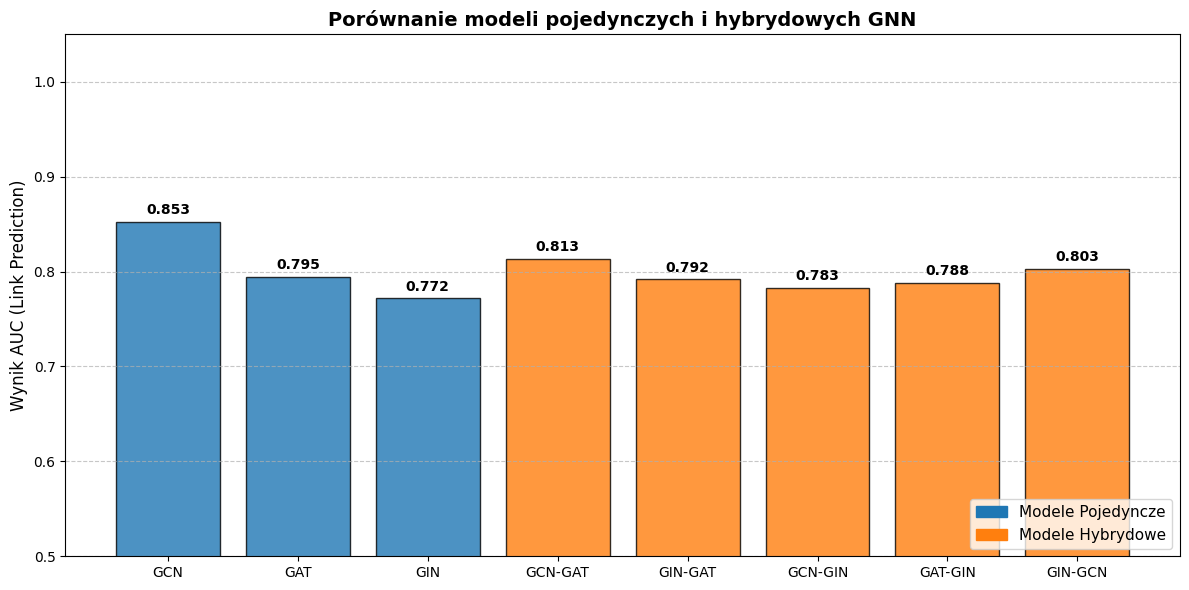

In [5]:
# ==========================================
# 5. GENEROWANIE WYKRESU (Jak w artykule!)
# ==========================================
names = list(results.keys())
scores = list(results.values())

# Kolorowanie: 3 pierwsze (Pojedyncze) na niebiesko, 5 kolejnych (Hybrydy) na pomarańczowo
colors = ['#1f77b4']*3 + ['#ff7f0e']*5

plt.figure(figsize=(12, 6))
bars = plt.bar(names, scores, color=colors, edgecolor='black', alpha=0.8)

# Dodanie wartości liczbowych nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha='center', va='bottom', fontweight='bold')

# Oś Y od 0.5 do 1.0 (bo poniżej 0.5 to model losowy)
plt.ylim(0.5, 1.05)
plt.ylabel('Wynik AUC (Link Prediction)', fontsize=12)
plt.title('Porównanie modeli pojedynczych i hybrydowych GNN', fontsize=14, fontweight='bold')

# Legenda (symulowana)
import matplotlib.patches as mpatches
single_patch = mpatches.Patch(color='#1f77b4', label='Modele Pojedyncze')
hybrid_patch = mpatches.Patch(color='#ff7f0e', label='Modele Hybrydowe')
plt.legend(handles=[single_patch, hybrid_patch], loc='lower right', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
# ==========================================
# 2. MODELE Z DODANYM DROPOUTEM (Klucz do sukcesu!)
# ==========================================
class GCN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training) # <--- ZABEZPIECZENIE PRZED PRZEUCZENIEM
        return self.conv2(x, edge_index)

class GAT_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        # Dodajemy 'heads=2', żeby model atencji był stabilniejszy
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class GIN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp1 = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp1, train_eps=True) # train_eps pozwala modelowi lepiej się uczyć
        mlp2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp2, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GCN_GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GAT_GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        mlp = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

# ==========================================
# 3. ZAKTUALIZOWANA FUNKCJA TRENUJĄCA
# ==========================================
def train_and_test(model, name):
    # Dodajemy 'weight_decay', co ogranicza dziki wzrost wag w potężnych modelach
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Zwiększamy liczbę epok do 150
    for epoch in range(1, 31):
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        out = decode(z, train_data.edge_label_index)
        loss = criterion(out, train_data.edge_label.float())
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        z = model.encode(test_data.x, test_data.edge_index)
        out = decode(z, test_data.edge_label_index).sigmoid()
        auc = roc_auc_score(test_data.edge_label.cpu().numpy(), out.cpu().numpy())
        print(f"[{name}] AUC: {auc:.4f}")
        return auc

# (Odpalamy np. z wybraną garstką)
in_channels = dataset.num_features
hidden_channels = 64

models = {
    "GCN": GCN_Net(in_channels, hidden_channels),
    "GAT": GAT_Net(in_channels, hidden_channels),
    "GIN": GIN_Net(in_channels, hidden_channels),
    "GCN-GAT": Hybrid_GCN_GAT(in_channels, hidden_channels),
    "GAT-GIN": Hybrid_GAT_GIN(in_channels, hidden_channels)
}

print("Rozpoczynamy zoptymalizowany trening...\n")
results = {}
for name, model in models.items():
    results[name] = train_and_test(model, name)

Rozpoczynamy zoptymalizowany trening...

[GCN] AUC: 0.8818
[GAT] AUC: 0.8622
[GIN] AUC: 0.7182
[GCN-GAT] AUC: 0.8508
[GAT-GIN] AUC: 0.8466


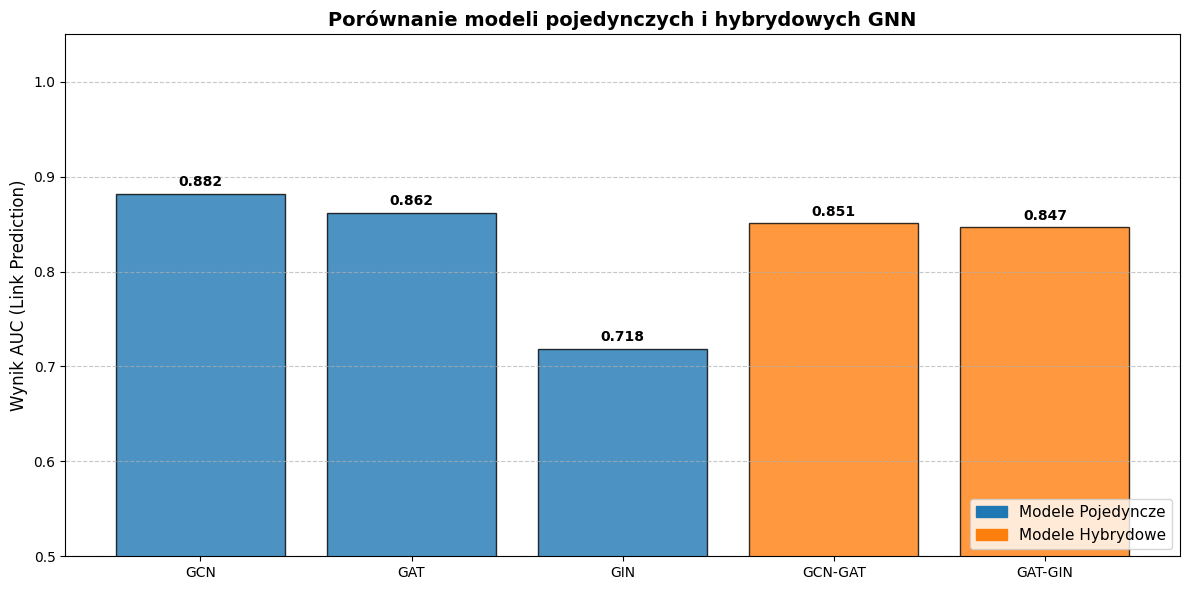

In [13]:
# ==========================================
# 5. GENEROWANIE WYKRESU (Jak w artykule!)
# ==========================================
names = list(results.keys())
scores = list(results.values())

# Kolorowanie: 3 pierwsze (Pojedyncze) na niebiesko, 5 kolejnych (Hybrydy) na pomarańczowo
colors = ['#1f77b4']*3 + ['#ff7f0e']*5

plt.figure(figsize=(12, 6))
bars = plt.bar(names, scores, color=colors, edgecolor='black', alpha=0.8)

# Dodanie wartości liczbowych nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha='center', va='bottom', fontweight='bold')

# Oś Y od 0.5 do 1.0 (bo poniżej 0.5 to model losowy)
plt.ylim(0.5, 1.05)
plt.ylabel('Wynik AUC (Link Prediction)', fontsize=12)
plt.title('Porównanie modeli pojedynczych i hybrydowych GNN', fontsize=14, fontweight='bold')

# Legenda (symulowana)
import matplotlib.patches as mpatches
single_patch = mpatches.Patch(color='#1f77b4', label='Modele Pojedyncze')
hybrid_patch = mpatches.Patch(color='#ff7f0e', label='Modele Hybrydowe')
plt.legend(handles=[single_patch, hybrid_patch], loc='lower right', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
from torch_geometric.datasets import WikipediaNetwork

# Pobieramy zbiór Chameleon (dużo szumu, wyższa trudność dla GCN)
print("Pobieranie zaszumionego zbioru Chameleon...")
dataset = WikipediaNetwork(root='data/Chameleon', name='chameleon')
data = dataset[0]

# Dalej kod idzie dokładnie tak samo...
transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=True
)

Pobieranie zaszumionego zbioru Chameleon...


Processing...
Done!


Dane podzielone! Liczba węzłów: 2277, Liczba cech: 2325

Rozpoczynamy masowy trening 8 modeli na trudnym grafie...

[GCN] Zakończono! AUC: 0.9698
[GAT] Zakończono! AUC: 0.9629
[GIN] Zakończono! AUC: 0.9153
[GCN-GAT] Zakończono! AUC: 0.9492
[GIN-GAT] Zakończono! AUC: 0.9425
[GCN-GIN] Zakończono! AUC: 0.9751
[GAT-GIN] Zakończono! AUC: 0.9771
[GIN-GCN] Zakończono! AUC: 0.9730


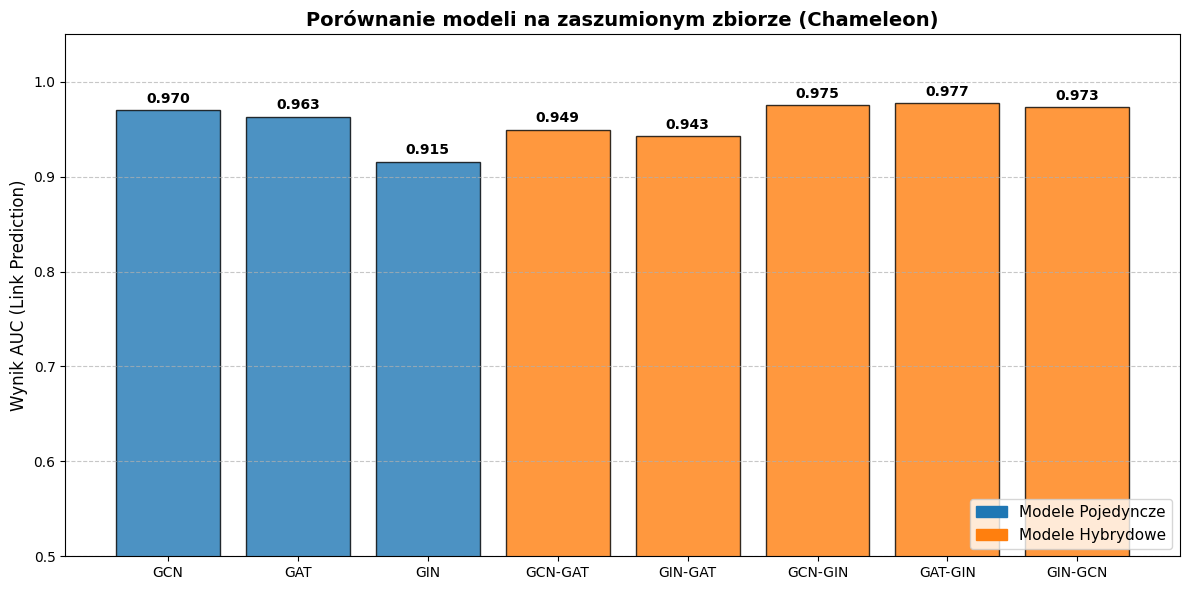

In [16]:
train_data, val_data, test_data = transform(dataset[0])

print(f"Dane podzielone! Liczba węzłów: {train_data.num_nodes}, Liczba cech: {dataset.num_features}\n")

# ==========================================
# 2. DEFINICJE MODELI (Wersja PRO z Dropoutem)
# ==========================================
def decode(z, edge_label_index):
    return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

class GCN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class GAT_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class GIN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp1 = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp1, train_eps=True)
        mlp2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp2, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

# --- HYBRYDY ---
class Hybrid_GCN_GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GIN_GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp, train_eps=True)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GCN_GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        mlp = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GAT_GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        mlp = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GIN_GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp, train_eps=True)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

# ==========================================
# 3. FUNKCJA TRENUJĄCA
# ==========================================
def train_and_test(model, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    for epoch in range(1, 101): # Zwiększono do 100 epok dla trudniejszego grafu
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        out = decode(z, train_data.edge_label_index)
        loss = criterion(out, train_data.edge_label.float())
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        z = model.encode(test_data.x, test_data.edge_index)
        out = decode(z, test_data.edge_label_index).sigmoid()
        auc = roc_auc_score(test_data.edge_label.cpu().numpy(), out.cpu().numpy())
        print(f"[{name}] Zakończono! AUC: {auc:.4f}")
        return auc

# ==========================================
# 4. START EKSPERYMENTU
# ==========================================
in_channels = dataset.num_features
hidden_channels = 64

models = {
    "GCN": GCN_Net(in_channels, hidden_channels),
    "GAT": GAT_Net(in_channels, hidden_channels),
    "GIN": GIN_Net(in_channels, hidden_channels),
    "GCN-GAT": Hybrid_GCN_GAT(in_channels, hidden_channels),
    "GIN-GAT": Hybrid_GIN_GAT(in_channels, hidden_channels),
    "GCN-GIN": Hybrid_GCN_GIN(in_channels, hidden_channels),
    "GAT-GIN": Hybrid_GAT_GIN(in_channels, hidden_channels),
    "GIN-GCN": Hybrid_GIN_GCN(in_channels, hidden_channels)
}

print("Rozpoczynamy masowy trening 8 modeli na trudnym grafie...\n")
results = {}
for name, model in models.items():
    results[name] = train_and_test(model, name)

# ==========================================
# 5. GENEROWANIE WYKRESU
# ==========================================
names = list(results.keys())
scores = list(results.values())
colors = ['#1f77b4']*3 + ['#ff7f0e']*5

plt.figure(figsize=(12, 6))
bars = plt.bar(names, scores, color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0.5, 1.05)
plt.ylabel('Wynik AUC (Link Prediction)', fontsize=12)
plt.title('Porównanie modeli na zaszumionym zbiorze (Chameleon)', fontsize=14, fontweight='bold')

import matplotlib.patches as mpatches
single_patch = mpatches.Patch(color='#1f77b4', label='Modele Pojedyncze')
hybrid_patch = mpatches.Patch(color='#ff7f0e', label='Modele Hybrydowe')
plt.legend(handles=[single_patch, hybrid_patch], loc='lower right', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Dane podzielone! Liczba węzłów: 2277, Liczba cech: 2325

Rozpoczynamy masowy trening 8 modeli na trudnym grafie...

[GCN] Zakończono! AUC: 0.9703
[GAT] Zakończono! AUC: 0.9614
[GIN] Zakończono! AUC: 0.7231
[GCN-GAT] Zakończono! AUC: 0.9512
[GIN-GAT] Zakończono! AUC: 0.9085
[GCN-GIN] Zakończono! AUC: 0.9618
[GAT-GIN] Zakończono! AUC: 0.9694
[GIN-GCN] Zakończono! AUC: 0.9617


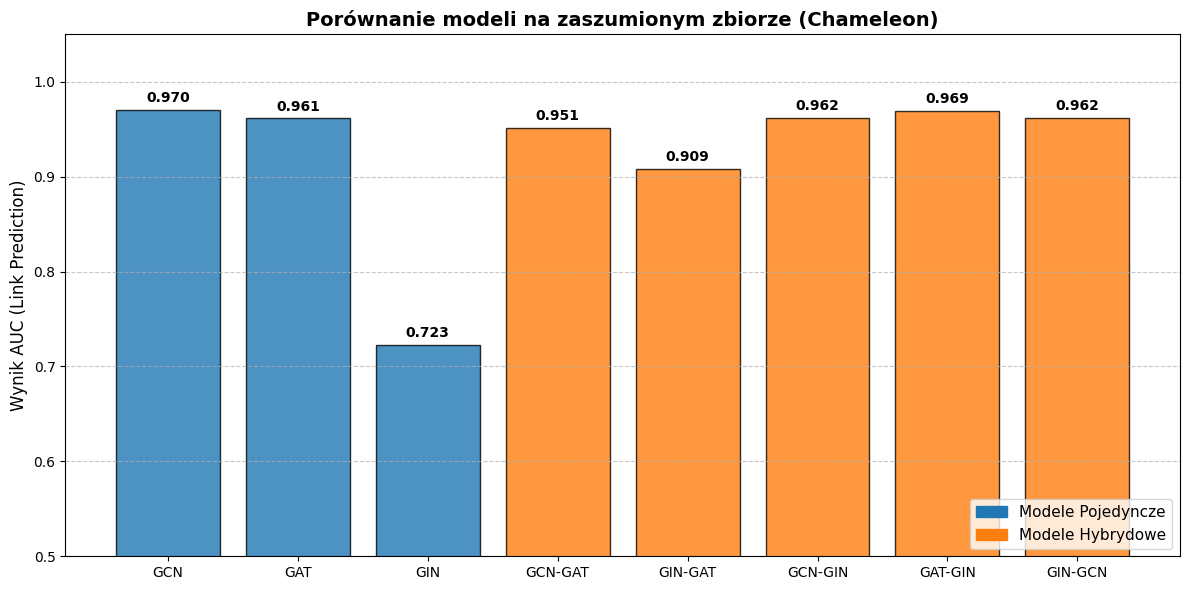

In [18]:
train_data, val_data, test_data = transform(dataset[0])

print(f"Dane podzielone! Liczba węzłów: {train_data.num_nodes}, Liczba cech: {dataset.num_features}\n")

# ==========================================
# 2. DEFINICJE MODELI (Wersja PRO z Dropoutem)
# ==========================================
def decode(z, edge_label_index):
    return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

class GCN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class GAT_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class GIN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp1 = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp1, train_eps=True)
        mlp2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp2, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

# --- HYBRYDY ---
class Hybrid_GCN_GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GIN_GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp, train_eps=True)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GCN_GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        mlp = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GAT_GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        mlp = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GIN_GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp, train_eps=True)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

# ==========================================
# 3. FUNKCJA TRENUJĄCA
# ==========================================
def train_and_test(model, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    for epoch in range(1, 51): # Zwiększono do 100 epok dla trudniejszego grafu
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        out = decode(z, train_data.edge_label_index)
        loss = criterion(out, train_data.edge_label.float())
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        z = model.encode(test_data.x, test_data.edge_index)
        out = decode(z, test_data.edge_label_index).sigmoid()
        auc = roc_auc_score(test_data.edge_label.cpu().numpy(), out.cpu().numpy())
        print(f"[{name}] Zakończono! AUC: {auc:.4f}")
        return auc

# ==========================================
# 4. START EKSPERYMENTU
# ==========================================
in_channels = dataset.num_features
hidden_channels = 64

models = {
    "GCN": GCN_Net(in_channels, hidden_channels),
    "GAT": GAT_Net(in_channels, hidden_channels),
    "GIN": GIN_Net(in_channels, hidden_channels),
    "GCN-GAT": Hybrid_GCN_GAT(in_channels, hidden_channels),
    "GIN-GAT": Hybrid_GIN_GAT(in_channels, hidden_channels),
    "GCN-GIN": Hybrid_GCN_GIN(in_channels, hidden_channels),
    "GAT-GIN": Hybrid_GAT_GIN(in_channels, hidden_channels),
    "GIN-GCN": Hybrid_GIN_GCN(in_channels, hidden_channels)
}

print("Rozpoczynamy masowy trening 8 modeli na trudnym grafie...\n")
results = {}
for name, model in models.items():
    results[name] = train_and_test(model, name)

# ==========================================
# 5. GENEROWANIE WYKRESU
# ==========================================
names = list(results.keys())
scores = list(results.values())
colors = ['#1f77b4']*3 + ['#ff7f0e']*5

plt.figure(figsize=(12, 6))
bars = plt.bar(names, scores, color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0.5, 1.05)
plt.ylabel('Wynik AUC (Link Prediction)', fontsize=12)
plt.title('Porównanie modeli na zaszumionym zbiorze (Chameleon)', fontsize=14, fontweight='bold')

import matplotlib.patches as mpatches
single_patch = mpatches.Patch(color='#1f77b4', label='Modele Pojedyncze')
hybrid_patch = mpatches.Patch(color='#ff7f0e', label='Modele Hybrydowe')
plt.legend(handles=[single_patch, hybrid_patch], loc='lower right', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Generowanie grafu z sygnałem (10,000 węzłów)...
Trening: GCN...
Wynik AUC dla GCN: 0.6049
Trening: GAT...
Wynik AUC dla GAT: 0.5216
Trening: GIN...
Wynik AUC dla GIN: 0.5000
Trening: GAT-GIN (Hybrid)...
Wynik AUC dla GAT-GIN (Hybrid): 0.6410
Trening: GIN-GAT (Hybrid)...
Wynik AUC dla GIN-GAT (Hybrid): 0.5213


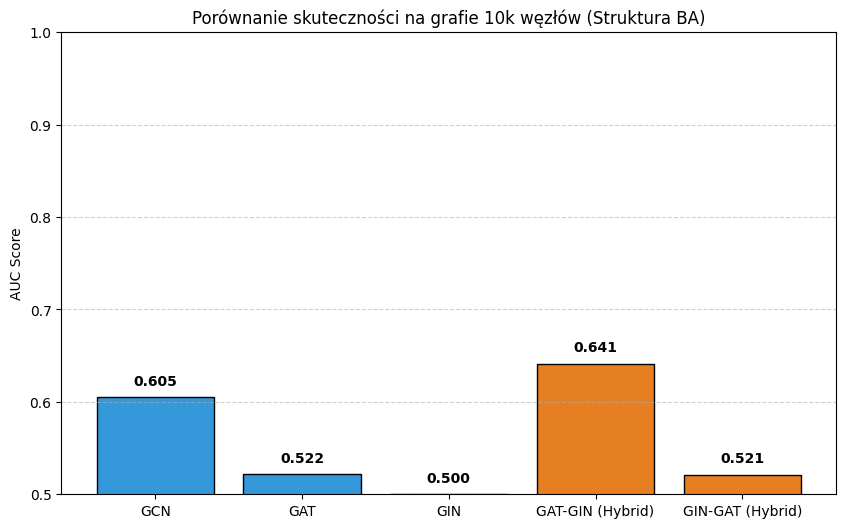

In [29]:
import torch
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU
from torch_geometric.data import Data
import torch_geometric.utils as utils
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv, GATConv, GINConv
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. GENEROWANIE DUŻEGO GRAFU SYNTETYCZNEGO
# ==========================================
# ==========================================
# 1. GENEROWANIE GRAFU "Z SYMULOWANYM SLANGIEM"
# ==========================================
print("Generowanie grafu z sygnałem (10,000 węzłów)...")

num_nodes = 10000
num_features = 64

# Struktura Barabási-Albert (liderzy i obserwujący)
edge_index = utils.barabasi_albert_graph(num_nodes, num_edges=4)

# --- SYMULACJA SYGNAŁU (Hashtagów) ---
# Zamiast czystego szumu, tworzymy "centra zainteresowań"
x = torch.zeros((num_nodes, num_features))
for i in range(num_nodes):
    # Węzły o niskich indeksach to nasi "dilerzy/liderzy"
    # Nadajemy im specyficzny wzorzec cech (np. jedynki na początku wektora)
    if i < 500:
        x[i, :10] = 1.0 + torch.randn(10) * 0.1 # "Slang dilerów"
    else:
        x[i, :] = torch.randn(num_features) # "Szum zwykłych ludzi"

# Dodajemy informację o stopniu węzła (GIN to uwielbia!)
deg = utils.degree(edge_index[0], num_nodes).view(-1, 1)
x = torch.cat([x, deg], dim=-1)

data = Data(x=x, edge_index=edge_index)

# Transformacja i Split
transform = T.Compose([
    T.ToUndirected(),
    T.RandomLinkSplit(num_val=0.05, num_test=0.15, is_undirected=True, add_negative_train_samples=True)
])
train_data, val_data, test_data = transform(data)

# ==========================================
# 2. DEFINICJE MODELI (Wersja PRO)
# ==========================================
def decode(z, edge_label_index):
    # Iloczyn skalarny - mierzymy podobieństwo wyliczonych profilów
    return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

class GCN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class GAT_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class GIN_Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp1 = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp1, train_eps=True)
        mlp2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp2, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

# --- HYBRYDY (GAT-GIN to Twoja główna broń) ---
class Hybrid_GAT_GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=2, concat=False)
        mlp = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(mlp, train_eps=True)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

class Hybrid_GIN_GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        mlp = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(mlp, train_eps=True)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=2, concat=False)
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

# ==========================================
# 3. PIPELINE TRENUJĄCY
# ==========================================
def train_and_test(model, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    print(f"Trening: {name}...")
    for epoch in range(1, 151): # 100 epok dla stabilności
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        out = decode(z, train_data.edge_label_index)
        loss = criterion(out, train_data.edge_label.float())
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        z = model.encode(test_data.x, test_data.edge_index)
        out = decode(z, test_data.edge_label_index).sigmoid()
        auc = roc_auc_score(test_data.edge_label.cpu().numpy(), out.cpu().numpy())
        print(f"Wynik AUC dla {name}: {auc:.4f}")
        return auc

# ==========================================
# 4. START EKSPERYMENTU
# ==========================================
hidden_channels = 64

# POBIERAMY DYNAMIKCZNIE LICZBĘ CECH Z DANYCH (BĘDZIE TO 65)
actual_in_channels = data.num_features

# Wybieramy kluczowe modele do porównania
models_to_run = {
    "GCN": GCN_Net(actual_in_channels, hidden_channels),
    "GAT": GAT_Net(actual_in_channels, hidden_channels),
    "GIN": GIN_Net(actual_in_channels, hidden_channels),
    "GAT-GIN (Hybrid)": Hybrid_GAT_GIN(actual_in_channels, hidden_channels),
    "GIN-GAT (Hybrid)": Hybrid_GIN_GAT(actual_in_channels, hidden_channels)
}

results = {}
for name, model in models_to_run.items():
    results[name] = train_and_test(model, name)

# ==========================================
# 5. GENEROWANIE WYKRESU
# ==========================================
plt.figure(figsize=(10, 6))
names = list(results.keys())
scores = list(results.values())
colors = ['#3498db']*3 + ['#e67e22']*2 # Niebieski dla solo, pomarańcz dla hybryd

bars = plt.bar(names, scores, color=colors, edgecolor='black')
plt.ylim(0.5, 1.0)
plt.ylabel('AUC Score')
plt.title('Porównanie skuteczności na grafie 10k węzłów (Struktura BA)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()